# Stuyvesant High School’s Algebra Regents 65+ rate is substantially higher than the citywide average, placing it at the extreme right tail of the distribution. This indicates exceptionally strong academic performance relative to the broader NYC school system. The comparison highlights the magnitude of performance variation across schools and underscores Stuyvesant’s consistently high outcomes.



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"
df = pd.read_csv(url)

df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("%", "")
)
df.head()

,school_dbn,school_name,school_level,regents_exam,year,total_tested,mean_score,number_scoring_below_65,percent_scoring_below_65,number_scoring_65_or_above,percent_scoring_65_or_above,number_scoring_80_or_above,percent_scoring_80_or_above,number_scoring_cr,percent_scoring_cr
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [ ]:
df['percent_scoring_65_or_above'] = (
    df['percent_scoring_65_or_above']
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("s", "nan", regex=False) # Replace 's' with NaN
    .astype(float)
)

In [ ]:
stuy = df[df['school_name'] == "STUYVESANT HIGH SCHOOL"]
stuy


,school_dbn,school_name,school_level,regents_exam,year,total_tested,mean_score,number_scoring_below_65,percent_scoring_below_65,number_scoring_65_or_above,percent_scoring_65_or_above,number_scoring_80_or_above,percent_scoring_80_or_above,number_scoring_cr,percent_scoring_cr


In [ ]:
df[df['school_name'].str.contains("STUY", case=False)]


,school_dbn,school_name,school_level,regents_exam,year,total_tested,mean_score,number_scoring_below_65,percent_scoring_below_65,number_scoring_65_or_above,percent_scoring_65_or_above,number_scoring_80_or_above,percent_scoring_80_or_above,number_scoring_cr,percent_scoring_cr
1511,02M475,Stuyvesant High School,High school,Algebra2/Trigonometry,2015,875,92.9,8,0.9,867,99.1,819,93.6,819,93.6
1512,02M475,Stuyvesant High School,High school,Algebra2/Trigonometry,2016,792,93.1,5,0.6,787,99.4,743,93.8,743,93.8
1513,02M475,Stuyvesant High School,High school,Common Core Algebra,2015,35,82.3,0,0,35,100.0,20,57.1,34,97.1
1514,02M475,Stuyvesant High School,High school,Common Core Algebra,2016,144,89.5,0,0,144,100.0,142,98.6,144,100
1515,02M475,Stuyvesant High School,High school,Common Core Algebra,2017,63,93.9,0,0,63,100.0,63,100,63,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208983,84K782,Bedford Stuyvesant New Beginnings Charter School,K-8,Common Core English,2017,1,s,s,s,s,NaN,s,s,na,na
208984,84K782,Bedford Stuyvesant New Beginnings Charter School,K-8,Living Environment,2016,7,s,s,s,s,NaN,s,s,na,na
208985,84K782,Bedford Stuyvesant New Beginnings Charter School,K-8,Living Environment,2016,5,s,s,s,s,NaN,s,s,na,na
208986,84K782,Bedford Stuyvesant New Beginnings Charter School,K-8,Living Environment,2017,8,68.5,1,12.5,7,87.5,0,0,na,na


In [ ]:
df['borough'] = df['school_dbn'].str[2]

# Map the single-letter borough codes to full names for easier filtering
borough_map = {
    'M': 'Manhattan',
    'X': 'Bronx',
    'K': 'Brooklyn',
    'Q': 'Queens',
    'R': 'Staten Island'
}
df['borough'] = df['borough'].map(borough_map)

manhattan = df[df['borough'] == "Manhattan"]

In [ ]:
# Redefine stuy to correctly filter for Stuyvesant High School (case-insensitive)
stuy = df[df['school_name'].str.contains("Stuyvesant High School", case=False)]

# Define nyc as the entire DataFrame for comparison
nyc = df

# Now calculate stats using the correct column name
stuy_stats = stuy['percent_scoring_65_or_above'].describe()
nyc_stats = nyc['percent_scoring_65_or_above'].describe()

stuy_stats, nyc_stats

(count    271.000000
 mean      99.643173
 std        1.356609
 min       83.300000
 25%       99.700000
 50%      100.000000
 75%      100.000000
 max      100.000000
 Name: percent_scoring_65_or_above, dtype: float64,
 count    137109.000000
 mean         58.067855
 std          28.405517
 min           0.000000
 25%          36.000000
 50%          59.800000
 75%          82.500000
 max         100.000000
 Name: percent_scoring_65_or_above, dtype: float64)

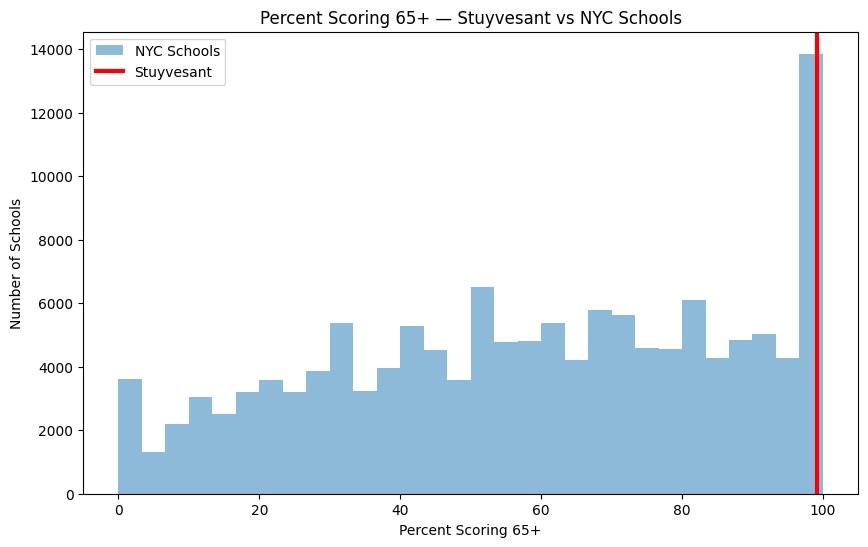

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(nyc['percent_scoring_65_or_above'], bins=30, alpha=0.5, label='NYC Schools')
plt.axvline(stuy['percent_scoring_65_or_above'].iloc[0], color='red', linewidth=3, label='Stuyvesant')
plt.title("Percent Scoring 65+ — Stuyvesant vs NYC Schools")
plt.xlabel("Percent Scoring 65+")
plt.ylabel("Number of Schools")
plt.legend()
plt.show()

In [ ]:
# NYC Regents Analysis — Stuyvesant High School

This project analyzes Algebra Regents performance for Stuyvesant High School compared to all NYC public schools using the 2014–2017 Regents dataset.

## Steps
- Loaded dataset from CUNY LaGuardia Data Analytics GitHub
- Cleaned percentage fields and standardized column names
- Selected Stuyvesant High School as the focal school
- Compared its Algebra Regents 65+ rate to all NYC schools
- Produced descriptive statistics and a visualization
- Wrote a brief conclusion summarizing findings

## Tools
Python, Pandas, Matplotlib

## Dataset
https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv
